# Basic EDA

In [144]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [145]:
df = pd.read_csv('classification_dataset.csv')
df.head(5)

,12,14,15,23,24,25,26,35,36,45,...,56,57,58,59,68,69,78,89,Average Stress,Average Mass
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,Low stress,High mass
1,1,1,0,1,1,0,1,0,1,1,...,1,1,1,0,0,0,0,0,Low stress,Medium mass
2,1,1,0,1,1,1,1,1,0,0,...,1,0,1,0,0,0,1,0,Low stress,Medium mass
3,1,1,0,1,0,0,1,0,1,1,...,1,1,1,0,0,0,0,0,Medium stress,Medium mass
4,1,1,0,1,0,1,1,1,0,0,...,1,0,1,0,0,0,1,0,Low stress,Medium mass


Text(0.5, 1.0, 'Stress Type')

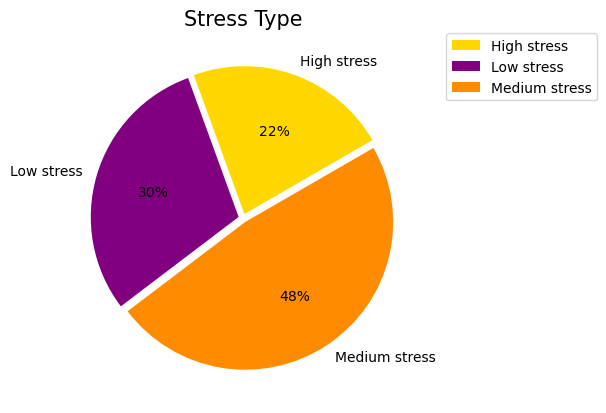

In [146]:
average_stress = df['Average Stress'].value_counts()
average_stress_df = average_stress.reset_index() 
average_stress_df.columns = "Stress Type", ""

colors = ['gold', 'purple', 'darkorange']
explode = (0.03, 0.03, 0.03)
average_stress_df.groupby(['Stress Type']).sum().plot(kind='pie', y="", autopct='%1.0f%%', colors=colors, explode=explode,
                                             startangle=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.title('Stress Type', fontsize = 15)

Text(0.5, 1.0, 'Mass')

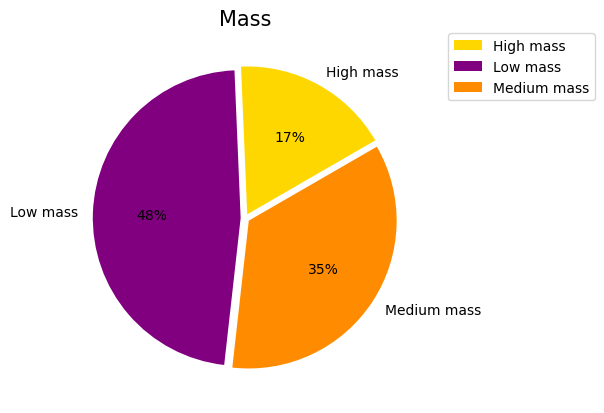

In [147]:
mass = df['Average Mass'].value_counts()
mass_df = mass.reset_index() 
mass_df.columns = "Mass", ""

colors = ['gold', 'purple', 'darkorange']
explode = (0.03, 0.03, 0.03)
mass_df.groupby(['Mass']).sum().plot(kind='pie', y="", autopct='%1.0f%%', colors=colors, explode=explode,
                                             startangle=30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.title('Mass', fontsize = 15)

In [148]:
df['stress_mass'] = df['Average Stress'] + ' ' + df['Average Mass']
df.head(5)

,12,14,15,23,24,25,26,35,36,45,...,57,58,59,68,69,78,89,Average Stress,Average Mass,stress_mass
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,Low stress,High mass,Low stress High mass
1,1,1,0,1,1,0,1,0,1,1,...,1,1,0,0,0,0,0,Low stress,Medium mass,Low stress Medium mass
2,1,1,0,1,1,1,1,1,0,0,...,0,1,0,0,0,1,0,Low stress,Medium mass,Low stress Medium mass
3,1,1,0,1,0,0,1,0,1,1,...,1,1,0,0,0,0,0,Medium stress,Medium mass,Medium stress Medium mass
4,1,1,0,1,0,1,1,1,0,0,...,0,1,0,0,0,1,0,Low stress,Medium mass,Low stress Medium mass


In [149]:
stress_mass = df['stress_mass'].value_counts()
stress_mass_df = stress_mass.reset_index() 
stress_mass_df.columns = "Stress and Mass", "Count"
stress_mass_df

,Stress and Mass,Count
0,Medium stress Low mass,62
1,Medium stress Medium mass,38
2,Low stress High mass,31
3,High stress Low mass,31
4,Low stress Medium mass,22
5,High stress Medium mass,19
6,Low stress Low mass,14
7,Medium stress High mass,8


In [150]:
new_row = ['High Stress High Mass', 0]
stress_mass_df.loc[len(stress_mass_df)] = new_row
stress_mass_df

,Stress and Mass,Count
0,Medium stress Low mass,62
1,Medium stress Medium mass,38
2,Low stress High mass,31
3,High stress Low mass,31
4,Low stress Medium mass,22
5,High stress Medium mass,19
6,Low stress Low mass,14
7,Medium stress High mass,8
8,High Stress High Mass,0


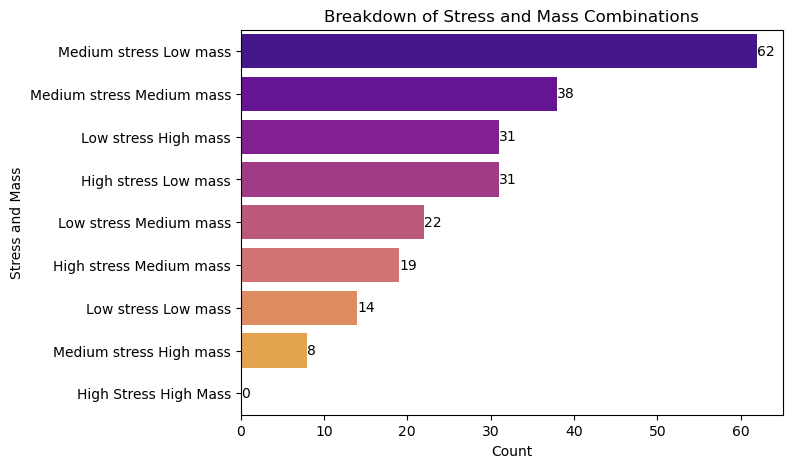

In [151]:
fig = plt.figure(figsize = (7,5))

ax = sns.barplot(x='Count', y='Stress and Mass', data=stress_mass_df, errwidth=0, palette = 'plasma')
ax.set_title("Breakdown of Stress and Mass Combinations")
ax.set_xlabel("Count")
ax.set_ylabel("Stress and Mass")
for i in ax.containers:
    ax.bar_label(i,)
plt.show()

In [152]:
zero_count = (df[["12","14","15","23","24","25","26","35","36","45","47","48","56","57","58","59","68","69","78","89"]]== 0).sum()
zero_count_df = zero_count.reset_index() 
zero_count_df.columns = "VC", "Count_0"
one_count = (df[["12","14","15","23","24","25","26","35","36","45","47","48","56","57","58","59","68","69","78","89"]]== 0).sum()
one_count_df = one_count.reset_index() 
one_count_df.columns = "VC", "Count_1"
merged_df = pd.merge(zero_count_df, one_count_df, on="VC")
merged_df

,VC,Count_0,Count_1
0,12,129,129
1,14,131,131
2,15,196,196
3,23,109,109
4,24,176,176
5,25,149,149
6,26,169,169
7,35,171,171
8,36,125,125
9,45,142,142


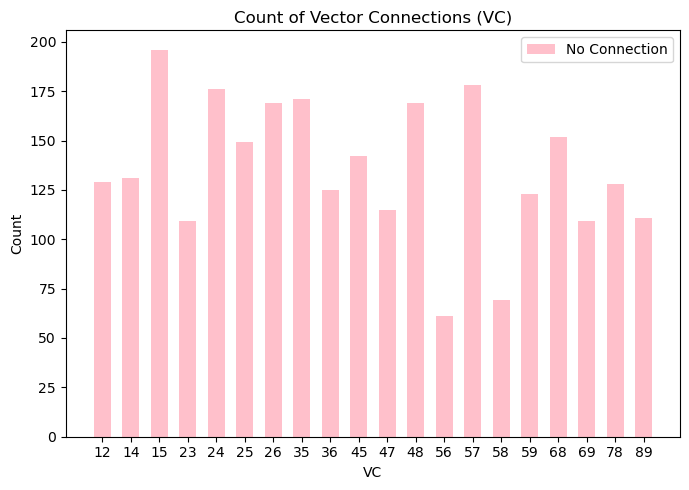

In [153]:
plt.figure(figsize=(7, 5))

# Set the width of the bars
bar_width = 0.6


# Create an array of indices for each "VC" to position bars
indices = np.arange(len(merged_df['VC']))

# Bar chart for Count_0
plt.bar(indices, merged_df['Count_1'], width=bar_width, color='pink', label='No Connection')

# Set x-axis ticks and labels
plt.xticks(indices, merged_df['VC'])

# Set labels and title
plt.xlabel('VC')
plt.ylabel('Count')
plt.title('Count of Vector Connections (VC)')

# Show legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

Shows that some VC have more connections than others which could cause bias in data. But this cannot be helped because some VC are compulsory to make viable structures.

# Data Loading and Splitting

In [154]:
from sklearn.model_selection import train_test_split 

In [155]:
X=df[["12","14","15","23","24","25","26","35","36","45","47","48","56","57","58","59","68","69","78","89"]]
Y=df["Average Stress"]

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=157)

In [156]:
X.head(5)

,12,14,15,23,24,25,26,35,36,45,47,48,56,57,58,59,68,69,78,89
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,0,1,1,0,1,0,1,1,1,1,1,1,1,0,0,0,0,0
2,1,1,0,1,1,1,1,1,0,0,1,1,1,0,1,0,0,0,1,0
3,1,1,0,1,0,0,1,0,1,1,1,1,1,1,1,0,0,0,0,0
4,1,1,0,1,0,1,1,1,0,0,1,1,1,0,1,0,0,0,1,0


In [157]:
Y.head(5)

0       Low stress
1       Low stress
2       Low stress
3    Medium stress
4       Low stress
Name: Average Stress, dtype: object

# Modelling

In [158]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Logistic Regression

In [159]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2']  # Type of regularization
}

# Create a logistic regression model
logreg = LogisticRegression()

# Perform grid search with cross-validation
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_logreg = LogisticRegression(**best_params)
best_logreg.fit(X_train, y_train)

# Evaluate on the validation set
val_accuracy = best_logreg.score(X_test, y_test)
print("Validation Accuracy:", val_accuracy)

Best Hyperparameters: {'C': 1, 'penalty': 'l2'}
Validation Accuracy: 0.8529411764705882


C:\Users\60124\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\60124\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [160]:
logreg = LogisticRegression(C=10, penalty='l2')
classifier_log = OneVsRestClassifier(logreg)
log_model = classifier_log.fit(X_train, y_train)

In [161]:
y_pred_log = classifier_log.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]
acc_log = classifier_log.score(X_test, y_test)
print('Accuracy of Logistic Regression classifier on test set: {:.7f}'.format(acc_log))

Accuracy of Logistic Regression classifier on test set: 0.8529412


In [162]:
cm_log = confusion_matrix(y_test, y_pred_log)
print(cm_log)

[[ 9  0  3]
 [ 0 14  5]
 [ 1  1 35]]


<AxesSubplot:>

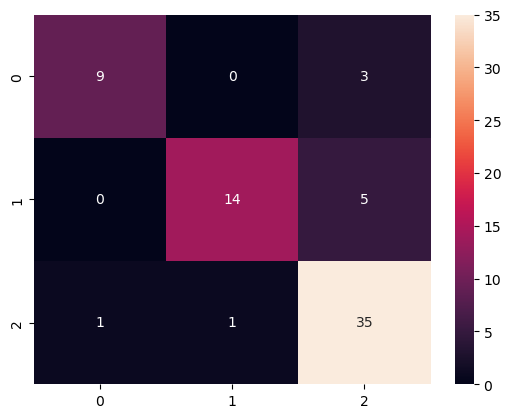

In [163]:
sns.heatmap(cm_log,annot=True)

In [164]:
print(classification_report(y_test, y_pred_log))

               precision    recall  f1-score   support

  High stress       0.90      0.75      0.82        12
   Low stress       0.93      0.74      0.82        19
Medium stress       0.81      0.95      0.88        37

     accuracy                           0.85        68
    macro avg       0.88      0.81      0.84        68
 weighted avg       0.86      0.85      0.85        68



## K-NN

Minimum error:- 0.19117647058823528 at K = 1


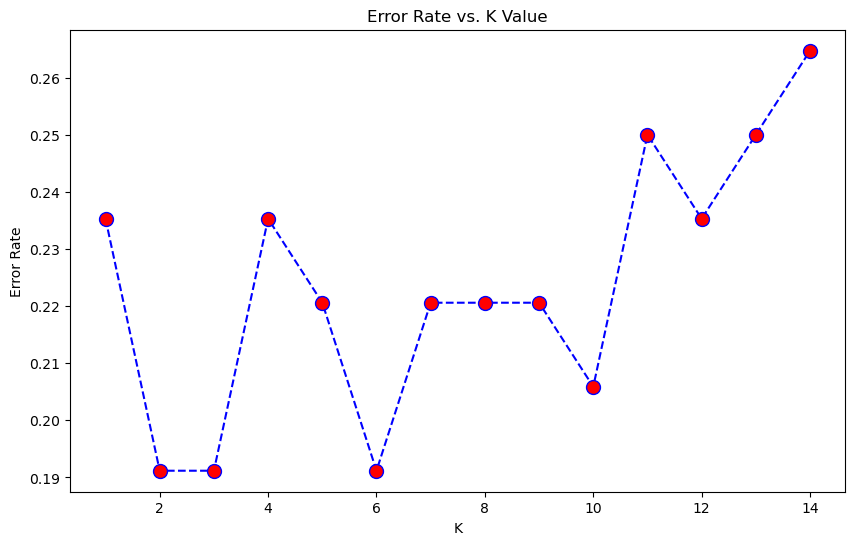

In [165]:
error_rate = []
for i in range(1,15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,15),error_rate,color='blue', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate)))

Maximum accuracy:- 0.8088235294117647 at K = 1


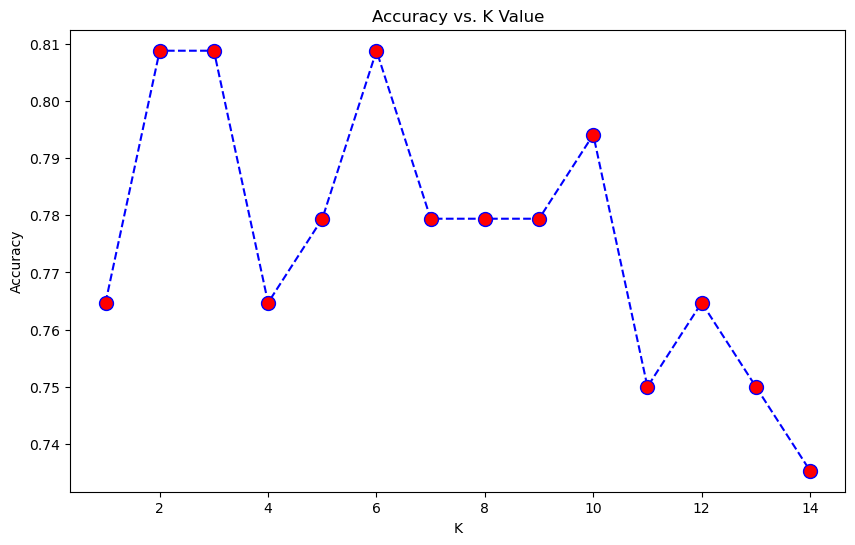

In [166]:
acc = []
for i in range(1,15):
    neigh = KNeighborsClassifier(n_neighbors = i).fit(X_train,y_train)
    yhat = neigh.predict(X_test)
    acc.append(metrics.accuracy_score(y_test, yhat))
    
plt.figure(figsize=(10,6))
plt.plot(range(1,15),acc,color = 'blue',linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Accuracy vs. K Value')
plt.xlabel('K')
plt.ylabel('Accuracy')
print("Maximum accuracy:-",max(acc),"at K =",acc.index(max(acc)))

In [167]:
knn = KNeighborsClassifier(n_neighbors=1)
classifier_knn = OneVsRestClassifier(knn)
knn_model = classifier_knn.fit(X_train, y_train)

In [168]:
y_pred_knn = classifier_knn.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]
acc_knn = classifier_knn.score(X_test, y_test)
print('Accuracy of K-NN classifier on test set: {:.7f}'.format(acc_knn))

Accuracy of K-NN classifier on test set: 0.7647059


In [169]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[ 9  0  3]
 [ 0 14  5]
 [ 3  5 29]]


<AxesSubplot:>

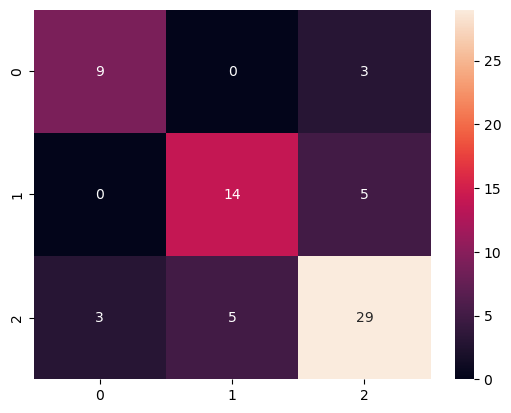

In [170]:
sns.heatmap(cm_knn,annot=True)

In [171]:
print(classification_report(y_test, y_pred_knn))

               precision    recall  f1-score   support

  High stress       0.75      0.75      0.75        12
   Low stress       0.74      0.74      0.74        19
Medium stress       0.78      0.78      0.78        37

     accuracy                           0.76        68
    macro avg       0.76      0.76      0.76        68
 weighted avg       0.76      0.76      0.76        68



## Decision Tree

In [172]:
# Define the hyperparameter grid for Decision Tree
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a Decision Tree model
dt_classifier = DecisionTreeClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_dt_classifier = DecisionTreeClassifier(**best_params, random_state=42)
best_dt_classifier.fit(X_train, y_train)

# Evaluate on the validation set
val_accuracy = best_dt_classifier.score(X_test, y_test)
print("Validation Accuracy:", val_accuracy)

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'best'}
Validation Accuracy: 0.7058823529411765


In [173]:
dt = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_leaf=1, min_samples_split=2, splitter='best')
classifier_dt = OneVsRestClassifier(dt)
dt_model = classifier_dt.fit(X_train, y_train)

In [174]:
y_pred_dt = classifier_dt.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
acc_dt = classifier_dt.score(X_test, y_test)
print('Accuracy of Decision Tree classifier on test set: {:.7f}'.format(acc_dt))

Accuracy of Decision Tree classifier on test set: 0.7941176


C:\Users\60124\anaconda3\lib\site-packages\sklearn\multiclass.py:492: RuntimeWarning: invalid value encountered in divide
  Y /= np.sum(Y, axis=1)[:, np.newaxis]


In [175]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[ 8  0  4]
 [ 1 11  7]
 [ 2  0 35]]


<AxesSubplot:>

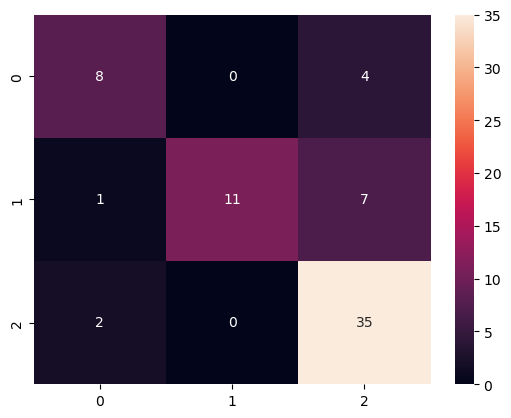

In [176]:
sns.heatmap(cm_dt,annot=True)

In [177]:
print(classification_report(y_test, y_pred_dt))

               precision    recall  f1-score   support

  High stress       0.73      0.67      0.70        12
   Low stress       1.00      0.58      0.73        19
Medium stress       0.76      0.95      0.84        37

     accuracy                           0.79        68
    macro avg       0.83      0.73      0.76        68
 weighted avg       0.82      0.79      0.79        68



## Random Forest

In [253]:
# Define the hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Create a Random Forest model
rf_classifier = RandomForestClassifier(random_state=42)

# Perform grid search with cross-validation
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters on the full training set
best_rf_classifier = RandomForestClassifier(**best_params, random_state=42)
best_rf_classifier.fit(X_train, y_train)

# Evaluate on the validation set
val_accuracy = best_rf_classifier.score(X_test, y_test)
print("Validation Accuracy:", val_accuracy)

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Validation Accuracy: 0.8676470588235294


In [254]:
rf = RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf= 1, min_samples_split= 2, n_estimators= 50, max_features = 'sqrt')
classifier_rf = OneVsRestClassifier(rf)
rf_model = classifier_rf.fit(X_train,y_train)

In [255]:
y_pred_rf = classifier_rf.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
acc_rf = classifier_rf.score(X_test, y_test)
print('Accuracy of Random Forest classifier on test set: {:.7f}'.format(acc_rf))

Accuracy of Random Forest classifier on test set: 0.8382353


In [256]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[ 9  0  3]
 [ 0 13  6]
 [ 1  1 35]]


<AxesSubplot:>

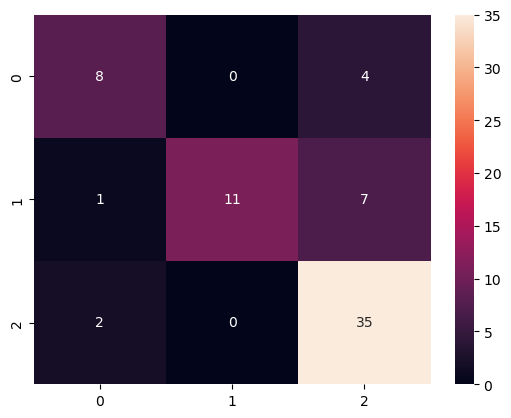

In [257]:
sns.heatmap(cm_dt,annot=True)

In [258]:
print(classification_report(y_test, y_pred_rf))

               precision    recall  f1-score   support

  High stress       0.90      0.75      0.82        12
   Low stress       0.93      0.68      0.79        19
Medium stress       0.80      0.95      0.86        37

     accuracy                           0.84        68
    macro avg       0.87      0.79      0.82        68
 weighted avg       0.85      0.84      0.83        68



## Support Vector Machine

In [259]:
# Define the hyperparameter grid for SVC
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1],
    'degree': [2, 3, 4]
}

# Create an SVC model
svc_classifier = SVC()

# Perform grid search with cross-validation
grid_search = GridSearchCV(svc_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_svc_classifier = SVC(**best_params)
best_svc_classifier.fit(X_train, y_train)

# Evaluate on the validation set
val_accuracy = best_svc_classifier.score(X_test, y_test)
print("Validation Accuracy:", val_accuracy)

Best Hyperparameters: {'C': 10, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
Validation Accuracy: 0.8088235294117647


In [260]:
svc = SVC(C= 100, degree= 2, gamma= 'scale', kernel= 'rbf',probability=True)
classifier_svc = OneVsRestClassifier(svc)
svc_model = classifier_svc.fit(X_train,y_train)

In [261]:
y_pred_svc = classifier_svc.predict(X_test)
y_proba_svc = svc_model.predict_proba(X_test)[:, 1]
acc_svc = classifier_svc.score(X_test, y_test)
print('Accuracy of Support Vector classifier on test set: {:.7f}'.format(acc_svc))

Accuracy of Support Vector classifier on test set: 0.8382353


In [262]:
cm_svc = confusion_matrix(y_test, y_pred_svc)
print(cm_svc)

[[10  0  2]
 [ 0 15  4]
 [ 1  4 32]]


<AxesSubplot:>

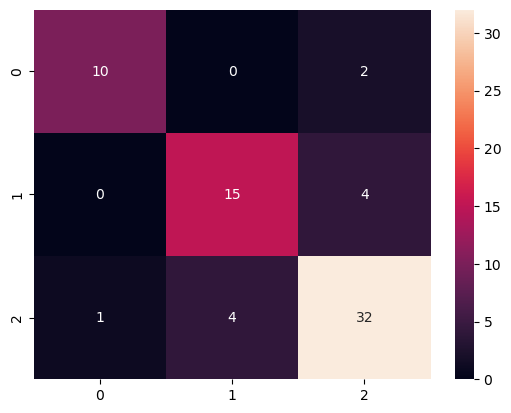

In [263]:
sns.heatmap(cm_svc,annot=True)

In [264]:
print(classification_report(y_test, y_pred_svc))

               precision    recall  f1-score   support

  High stress       0.91      0.83      0.87        12
   Low stress       0.79      0.79      0.79        19
Medium stress       0.84      0.86      0.85        37

     accuracy                           0.84        68
    macro avg       0.85      0.83      0.84        68
 weighted avg       0.84      0.84      0.84        68



# Evaluation

In [265]:
from sklearn.model_selection import cross_val_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score

## Model Accuracy Comparison

| Models                                                       	| Accuracy on Testing Set 	|
|:-------------------------------------------------------------	|:-------------------------:|
| Logistic Regression                                       	| X               	        |
| K Nearest Neighbor                                        	| X                      	|  
| Decision Tree                                             	| X                     	| 
| Random Forest                                             	| X                      	|  
| Support Vector Machine                                    	| X                     	| 

Text(0, 0.5, 'Accuracy')

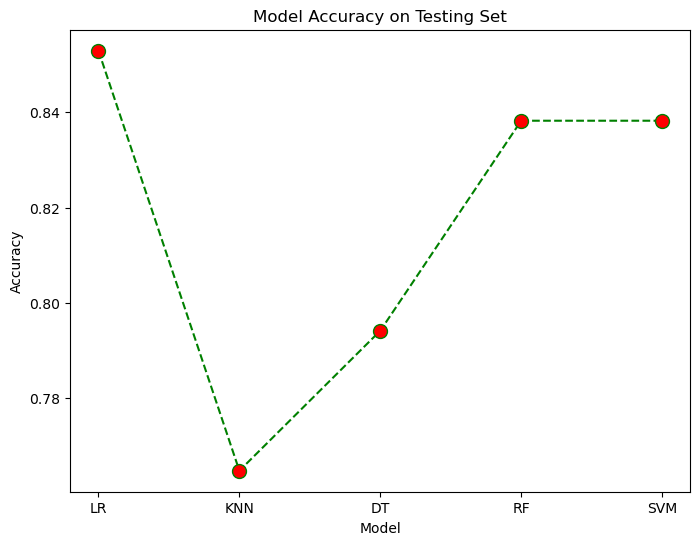

In [266]:
model_acc = [acc_log, acc_knn, acc_dt, acc_rf, acc_svc]
models = ['LR', 'KNN', 'DT', 'RF', 'SVM']

plt.figure(figsize=(8,6))
plt.plot(models, model_acc, color = 'green', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Model Accuracy on Testing Set')
plt.xlabel('Model')
plt.ylabel('Accuracy')

## K-Fold Cross Validation (w/ training data)

In [267]:
k = 5

"""LR"""
cv_scores_log = cross_val_score(log_model, X_train, y_train, cv=k)
cv_mean_log = cv_scores_log.mean()
print("Cross validation scores for LR:", cv_scores_log)
print("Mean cross validation score for LR: {:.7f}".format(cv_mean_log))
print()

"""KNN"""
cv_scores_knn = cross_val_score(knn_model, X_train, y_train, cv=k)
cv_mean_knn = cv_scores_knn.mean()
print("Cross validation scores for KNN:", cv_scores_knn)
print("Mean cross validation score for KNN: {:.7f}".format(cv_mean_knn))
print()

"""DT"""
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=k)
cv_mean_dt = cv_scores_dt.mean()
print("Cross validation scores for DT:", cv_scores_dt)
print("Mean cross validation score for DT: {:.7f}".format(cv_mean_dt))
print()

"""RF"""
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=k)
cv_mean_rf = cv_scores_rf.mean()
print("Cross validation scores for RF:", cv_scores_rf)
print("Mean cross validation score for RF: {:.7f}".format(cv_mean_rf))
print()

"""SVM"""
cv_scores_svc = cross_val_score(svc_model, X_train, y_train, cv=k)
cv_mean_svc = cv_scores_svc.mean()
print("Cross validation scores for SVM:", cv_scores_svc)
print("Mean cross validation score for SVM: {:.7f}".format(cv_mean_svc))

Cross validation scores for LR: [0.84375    0.75       0.87096774 0.83870968 0.77419355]
Mean cross validation score for LR: 0.8155242

Cross validation scores for KNN: [0.875      0.8125     0.93548387 0.80645161 0.77419355]
Mean cross validation score for KNN: 0.8407258

Cross validation scores for DT: [0.8125     0.84375    0.80645161 0.74193548 0.77419355]
Mean cross validation score for DT: 0.7957661

Cross validation scores for RF: [0.875      0.8125     0.83870968 0.83870968 0.83870968]
Mean cross validation score for RF: 0.8407258

Cross validation scores for SVM: [0.96875    0.875      0.87096774 0.80645161 0.80645161]
Mean cross validation score for SVM: 0.8655242


| Models                                                       	| Mean Cross Validation Score 	|
|:-------------------------------------------------------------	|:-----------------------------:|
| Logistic Regression                                       	| X               	            |
| K Nearest Neighbor                                        	| X                      	    |  
| Decision Tree                                             	| X                     	    | 
| Random Forest                                             	| X                          	|  
| Support Vector Machine                                    	| X                     	    | 

Text(0, 0.5, 'Mean CV Score')

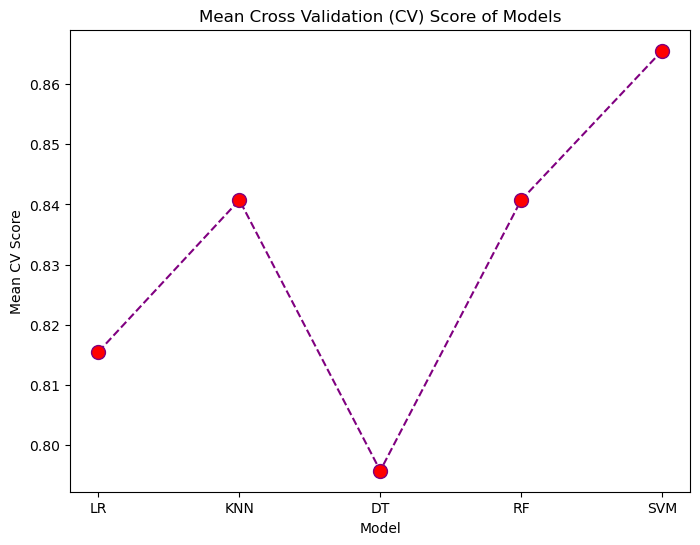

In [268]:
cv_mean = [cv_mean_log, cv_mean_knn, cv_mean_dt, cv_mean_rf, cv_mean_svc]
models = ['LR', 'KNN', 'DT', 'RF', 'SVM']

plt.figure(figsize=(8,6))
plt.plot(models, cv_mean, color = 'purple', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Mean Cross Validation (CV) Score of Models')
plt.xlabel('Model')
plt.ylabel('Mean CV Score')

## ROC Curve

In [269]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [270]:
y_bin = label_binarize(y_test, classes=['Low stress', 'Medium stress', 'High stress'])
label_names = ['Low stress', 'Medium stress', 'High stress']

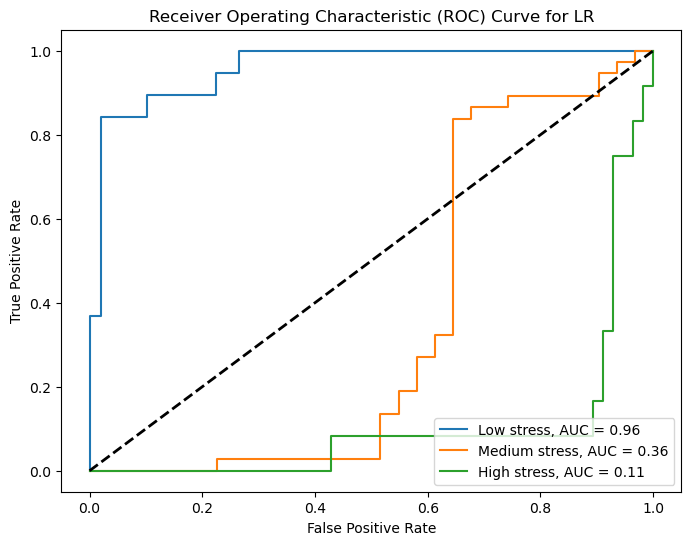

In [271]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
num_classes = y_bin.shape[1]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba_log)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Now you can plot or analyze the results for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{label_names[i]}, AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for LR')
plt.legend(loc="lower right")
plt.show()

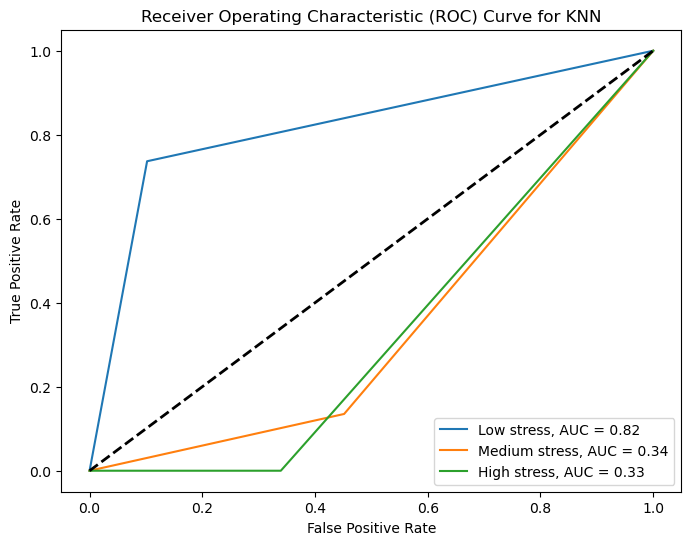

In [272]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
num_classes = y_bin.shape[1]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba_knn)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Now you can plot or analyze the results for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{label_names[i]}, AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN')
plt.legend(loc="lower right")
plt.show()

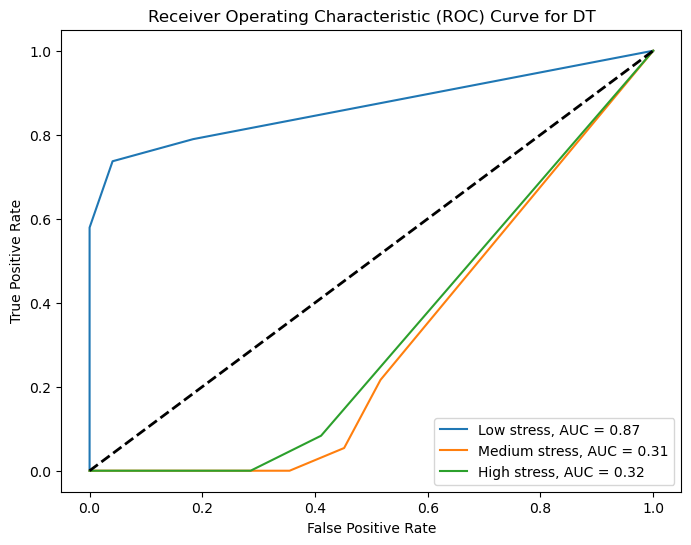

In [273]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
num_classes = y_bin.shape[1]
y_proba_dt = np.nan_to_num(y_proba_dt, nan=np.nanmean(y_proba_dt))

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba_dt)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Now you can plot or analyze the results for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{label_names[i]}, AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for DT')
plt.legend(loc="lower right")
plt.show()

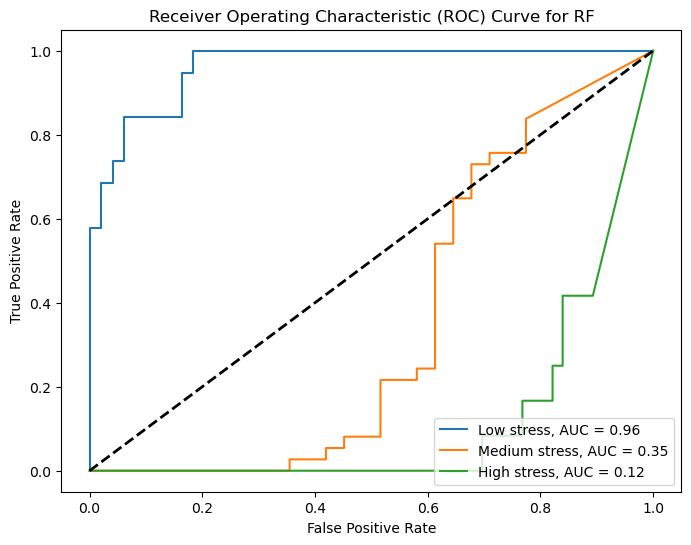

In [274]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
num_classes = y_bin.shape[1]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba_rf)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Now you can plot or analyze the results for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{label_names[i]}, AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for RF')
plt.legend(loc="lower right")
plt.show()

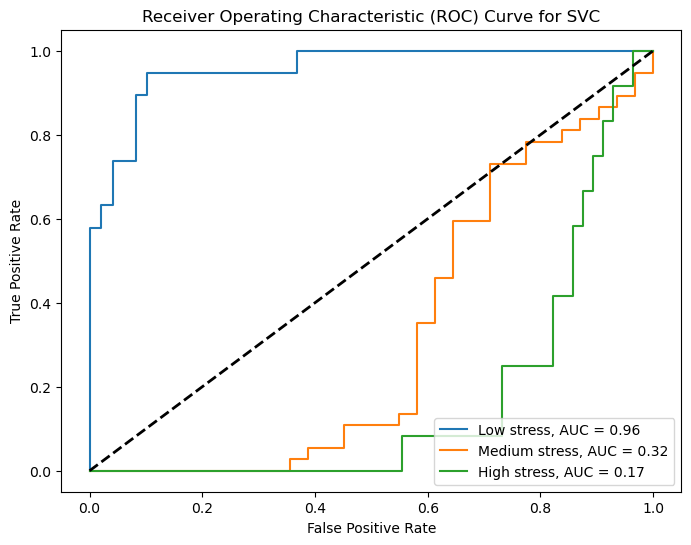

In [275]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
num_classes = y_bin.shape[1]

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba_svc)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Now you can plot or analyze the results for each class
plt.figure(figsize=(8, 6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f'{label_names[i]}, AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Plot the diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVC')
plt.legend(loc="lower right")
plt.show()

## Deployment - Forward Training

In [276]:
import gradio as gr

In [277]:
feature_labels = ["12","14","15","23","24","25","26","35","36","45","47","48","56","57","58","59","68","69","78","89"]

# Gradio interface with Checkbox input and custom labels
def predict_stress_level(*binary_features):
    # Make a prediction using the trained SVC model
    input_features = [int(feature) for feature in binary_features]
    prediction = svc_model.predict([input_features])[0]
    return str(prediction)

checkbox_inputs = [gr.Checkbox(label=label) for label in feature_labels]

iface = gr.Interface(fn=predict_stress_level, 
                    inputs=checkbox_inputs,
                    outputs="text",
                    live=True,
                    title="Stress Level Predictor",
                    description="Toggle 'yes' or 'no' for each feature to predict stress level (low, medium, or high)",
                    allow_flagging='never')

iface.launch()

C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_1
  warnings.warn(
C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_2
  warnings.warn(
C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_3
  warnings.warn(
C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_4
  warnings.warn(
C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_5
  warnings.warn(
C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_6
  warnings.warn(
C:\Users\60124\anaconda3\lib\site-packages\gradio\blocks.py:217: UserWarning: api_name predict already exists, using predict_7
  warning


Thanks for being a Gradio user! If you have questions or feedback, please join our Discord server and chat with us: https://discord.gg/feTf9x3ZSB
Running on local URL:  http://127.0.0.1:7865

To create a public link, set `share=True` in `launch()`.
